<a href="https://colab.research.google.com/github/khushivats0201/CODSOFT/blob/main/CREDIT_CARD_FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q imbalanced-learn

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, PrecisionRecallDisplay)
import joblib, warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fraudTest.csv to fraudTest.csv
Saving fraudTrain.csv to fraudTrain.csv


In [ ]:
train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")
df = pd.concat([train, test], ignore_index=True)
print("Combined shape:", df.shape)
df.head()


Combined shape: (1852394, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nStatistical summary:\n", df.describe().T)

class_counts = df['is_fraud'].value_counts()
class_pct = df['is_fraud'].value_counts(normalize=True) * 100
print("\nClass distribution:\n", class_counts)
print("\nClass percentage:\n", class_pct)


Shape: (1852394, 23)

Column dtypes:
 Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Missing values:
 Series([], dtype: int64)

Duplicate rows: 0

Statistical summary:
                 count          mean           std           min           25%  \
Unnamed: 0  1852394.0  

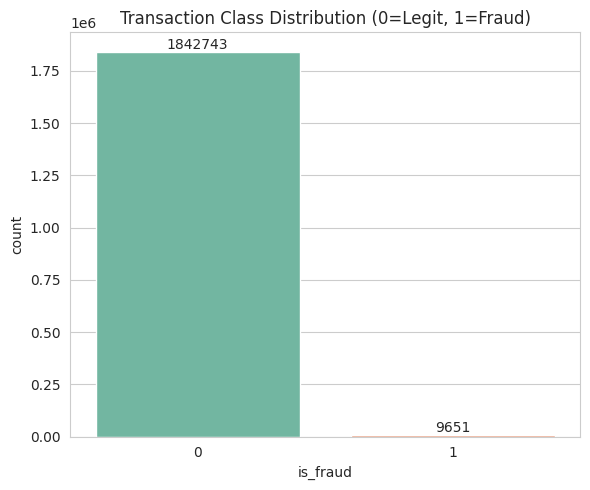

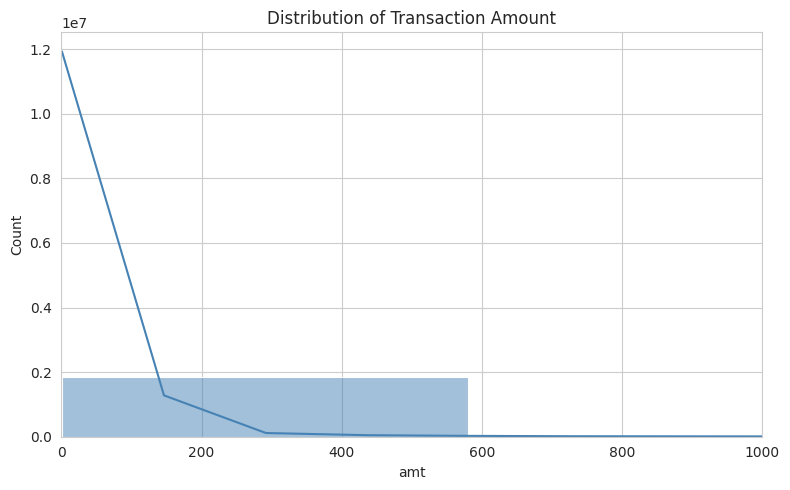

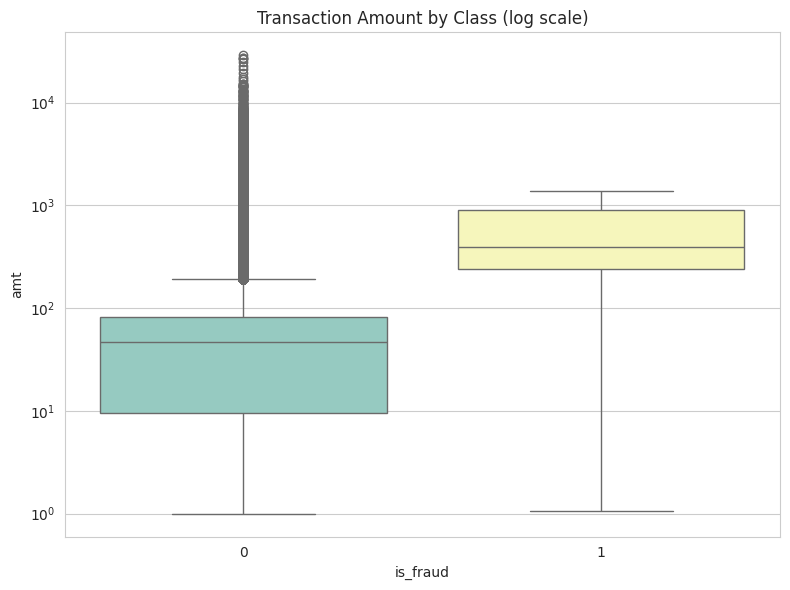

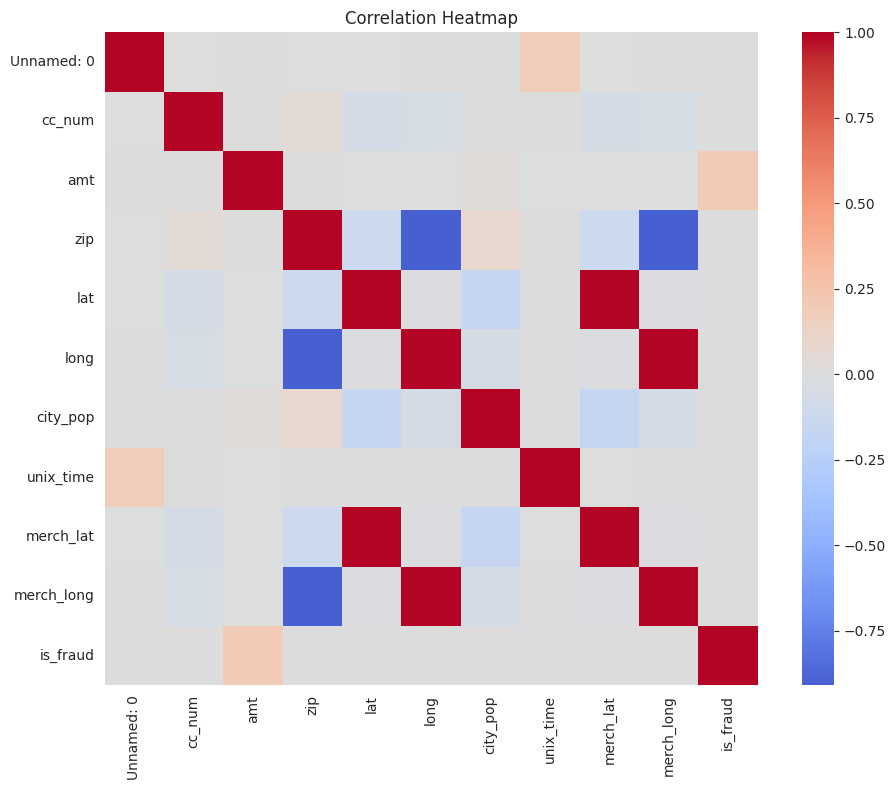

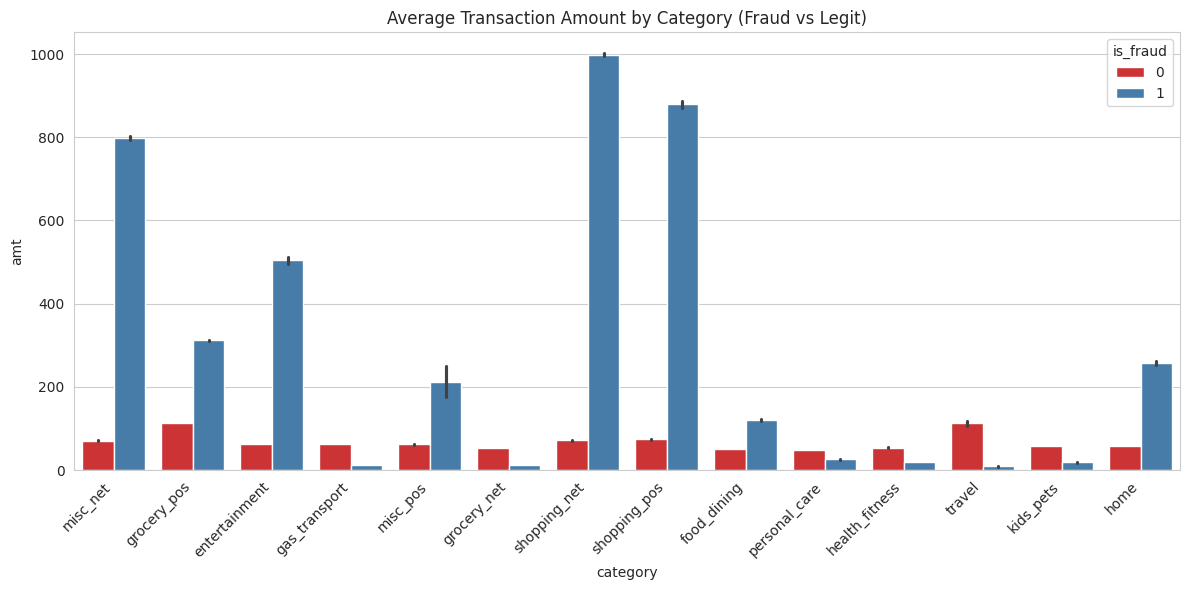

Observations:
- Fraud accounts for only 0.521% of transactions -> severe class imbalance.
- Fraudulent transactions tend to have higher average amounts and cluster in specific categories.
- Because of the imbalance, accuracy alone will be a misleading metric for evaluation.


In [ ]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='is_fraud', data=df, hue='is_fraud', palette='Set2', legend=False)
ax.set_title('Transaction Class Distribution (0=Legit, 1=Fraud)')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                 ha='center', va='bottom')
plt.tight_layout(); plt.show()

# Histogram of transaction amount
plt.figure(figsize=(8, 5))
sns.histplot(df['amt'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Transaction Amount')
plt.xlim(0, 1000)
plt.tight_layout(); plt.show()

# Boxplot of amount by class
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_fraud', y='amt', data=df, hue='is_fraud', palette='Set3', legend=False)
plt.yscale('log')
plt.title('Transaction Amount by Class (log scale)')
plt.tight_layout(); plt.show()

# Correlation heatmap (numeric columns only, sampled for speed)
plt.figure(figsize=(10, 8))
sample_df = df.sample(n=50000, random_state=RANDOM_STATE)
corr = sample_df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

# Fraud vs Non-Fraud: average amount by category
plt.figure(figsize=(12, 6))
sns.barplot(x='category', y='amt', hue='is_fraud', data=df, estimator=np.mean, palette='Set1')
plt.xticks(rotation=45, ha='right')
plt.title('Average Transaction Amount by Category (Fraud vs Legit)')
plt.tight_layout(); plt.show()

print("Observations:")
print(f"- Fraud accounts for only {class_pct[1]:.3f}% of transactions -> severe class imbalance.")
print("- Fraudulent transactions tend to have higher average amounts and cluster in specific categories.")
print("- Because of the imbalance, accuracy alone will be a misleading metric for evaluation.")


In [ ]:
# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# Remove duplicates
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate rows")

# Feature engineering from datetime columns
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

# Age of cardholder at time of transaction
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(int)

# Distance between cardholder location and merchant location (haversine, km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

# Drop identifier / high-cardinality / now-unused columns
drop_cols = ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'first', 'last',
              'street', 'city', 'state', 'zip', 'job', 'dob', 'trans_num', 'unix_time',
              'lat', 'long', 'merch_lat', 'merch_long']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Encode categorical variables
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
df = pd.get_dummies(df, columns=['category'], drop_first=True)

print("Final feature set shape:", df.shape)

# Separate features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Feature scaling
num_cols = ['amt', 'city_pop', 'hour', 'day', 'month', 'day_of_week', 'age', 'distance_km']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train fraud count:", y_train.sum(), "| Test fraud count:", y_test.sum())


Removed 0 duplicate rows
Final feature set shape: (1852394, 23)
Train shape: (1481915, 22) | Test shape: (370479, 22)
Train fraud count: 7721 | Test fraud count: 1930


In [ ]:
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio (legit:fraud) = {imbalance_ratio:.1f} : 1")

# Step 1: undersample majority class to 10x the minority class
under = RandomUnderSampler(sampling_strategy=0.1, random_state=RANDOM_STATE)
X_under, y_under = under.fit_resample(X_train, y_train)

# Step 2: SMOTE to bring minority class up to 50% of the majority class
smote = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_under, y_under)

print("Before balancing:", y_train.value_counts().to_dict())
print("After balancing :", y_train_bal.value_counts().to_dict())
print("Note: combining under-sampling + SMOTE keeps the balanced training set")
print("computationally manageable while still fixing the severe imbalance.")
print("All evaluation below uses the ORIGINAL, untouched, imbalanced test set.")


Imbalance ratio (legit:fraud) = 190.9 : 1
Before balancing: {0: 1474194, 1: 7721}
After balancing : {0: 77210, 1: 38605}
Note: combining under-sampling + SMOTE keeps the balanced training set
computationally manageable while still fixing the severe imbalance.
All evaluation below uses the ORIGINAL, untouched, imbalanced test set.


In [ ]:
print("Training Logistic Regression ...")
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_bal, y_train_bal)

print("Training Decision Tree ...")
dec_tree = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE)
dec_tree.fit(X_train_bal, y_train_bal)

print("Training Random Forest ...")
rand_forest = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=2,
                                       n_jobs=-1, random_state=RANDOM_STATE)
rand_forest.fit(X_train_bal, y_train_bal)

models = {"Logistic Regression": log_reg, "Decision Tree": dec_tree, "Random Forest": rand_forest}
print("All models trained.")


Training Logistic Regression ...
Training Decision Tree ...
Training Random Forest ...
All models trained.



--- Logistic Regression ---
Confusion Matrix:
[[357469  11080]
 [   504   1426]]

--- Decision Tree ---
Confusion Matrix:
[[362191   6358]
 [   104   1826]]

--- Random Forest ---
Confusion Matrix:
[[366191   2358]
 [   183   1747]]

Model Comparison Table:

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.9687     0.1140  0.7389    0.1976   0.9139
Decision Tree          0.9826     0.2231  0.9461    0.3611   0.9935
Random Forest          0.9931     0.4256  0.9052    0.5790   0.9941


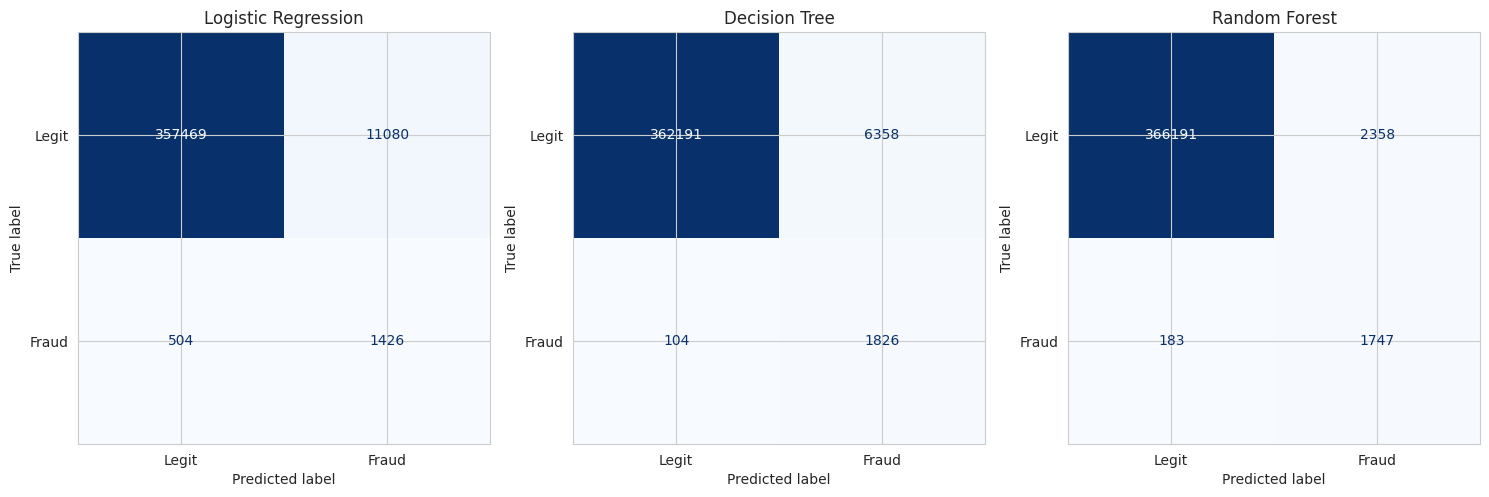

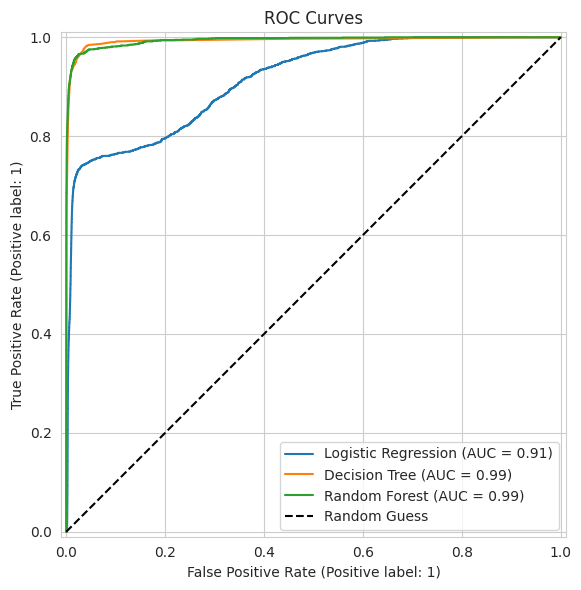

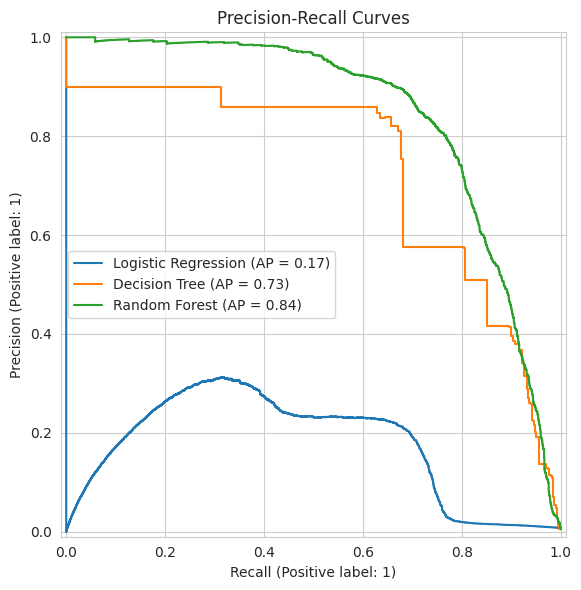


Best model based on F1 Score & ROC-AUC: Random Forest

Why accuracy alone is insufficient: fraud is <1% of transactions, so a model
predicting 'legit' for everything would still score >99% accuracy while catching
zero fraud. Precision, Recall, F1, and ROC-AUC reveal true fraud-detection ability.


In [ ]:
results, predictions, probabilities = [], {}, {}

for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    predictions[name], probabilities[name] = pred, proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    print(f"\n--- {name} ---")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, pred)}")

results_df = pd.DataFrame(results).set_index("Model")
print("\nModel Comparison Table:\n")
print(results_df.round(4))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, predictions[name]),
                            display_labels=["Legit", "Fraud"]).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
ax = plt.gca()
for name in models:
    RocCurveDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curves'); plt.legend(); plt.tight_layout(); plt.show()

# Precision-Recall curves
plt.figure(figsize=(8, 6))
ax = plt.gca()
for name in models:
    PrecisionRecallDisplay.from_predictions(y_test, probabilities[name], name=name, ax=ax)
plt.title('Precision-Recall Curves'); plt.legend(); plt.tight_layout(); plt.show()

best_model_name = results_df.sort_values(by=["F1 Score", "ROC-AUC"], ascending=False).index[0]
best_model = models[best_model_name]
print(f"\nBest model based on F1 Score & ROC-AUC: {best_model_name}")
print("\nWhy accuracy alone is insufficient: fraud is <1% of transactions, so a model")
print("predicting 'legit' for everything would still score >99% accuracy while catching")
print("zero fraud. Precision, Recall, F1, and ROC-AUC reveal true fraud-detection ability.")


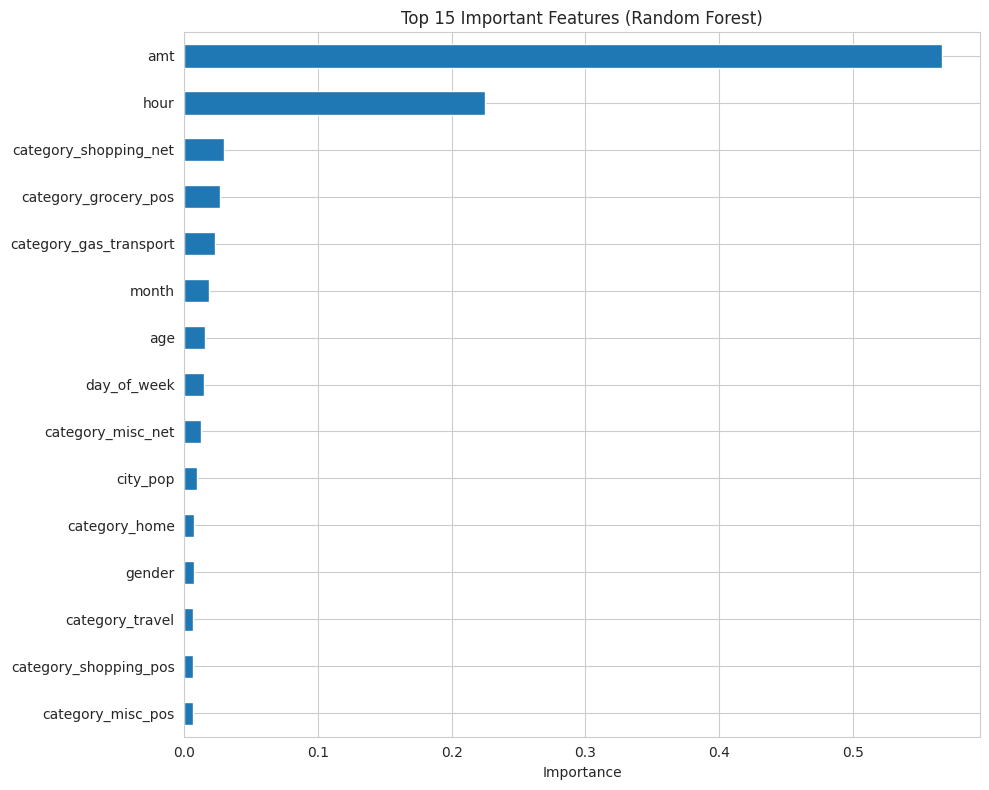

Top features:
 amt                       0.566718
hour                      0.224502
category_shopping_net     0.029955
category_grocery_pos      0.026858
category_gas_transport    0.022868
month                     0.018297
age                       0.015803
day_of_week               0.014488
category_misc_net         0.012504
city_pop                  0.009639
dtype: float64

Features like 'amt' (transaction amount), 'distance_km' (distance between
cardholder and merchant), and 'hour'/'day_of_week' typically rank highest,
since unusually large amounts, distant transactions, or odd-hour purchases
are strong fraud indicators.


In [ ]:
importances = pd.Series(rand_forest.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Important Features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

print("Top features:\n", importances.head(10))
print("\nFeatures like 'amt' (transaction amount), 'distance_km' (distance between")
print("cardholder and merchant), and 'hour'/'day_of_week' typically rank highest,")
print("since unusually large amounts, distant transactions, or odd-hour purchases")
print("are strong fraud indicators.")


In [ ]:
def predict_transaction(transaction_dict, model=best_model, columns=X.columns,
                          scaler=scaler, num_cols=num_cols):
    """
    transaction_dict: dict with the same raw keys as the engineered feature set
                       (after feature engineering), e.g.:
                       {'amt':250.0, 'gender':1, 'city_pop':5000, 'hour':2, 'day':15,
                        'month':6, 'day_of_week':3, 'age':35, 'distance_km':80,
                        'category_food_dining':0, ... all other category_ dummies: 0}
    """
    input_df = pd.DataFrame([transaction_dict])
    # Ensure all expected columns exist, fill missing with 0
    for col in columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[columns]
    input_df[num_cols] = scaler.transform(input_df[num_cols])

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0][1]
    label = "Fraudulent Transaction" if pred == 1 else "Legitimate Transaction"
    print(f"Prediction: {label}")
    print(f"Probability of Fraud: {proba*100:.2f}%")
    return label, proba

# Example usage with a real test-set row
sample_transaction = X_test.iloc[0].to_dict()
predict_transaction(sample_transaction)


Prediction: Legitimate Transaction
Probability of Fraud: 20.81%


('Legitimate Transaction', np.float64(0.20812485287680893))

In [ ]:
joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print(f"Saved best model ({best_model_name}) to fraud_model.pkl")

# Demonstrate loading and predicting
loaded_model = joblib.load("fraud_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

sample = X_test.iloc[1:2]
loaded_pred = loaded_model.predict(sample)[0]
loaded_proba = loaded_model.predict_proba(sample)[0][1]
print(f"Loaded model prediction: {'Fraudulent' if loaded_pred==1 else 'Legitimate'} "
      f"({loaded_proba*100:.2f}% probability of fraud)")







Saved best model (Random Forest) to fraud_model.pkl
Loaded model prediction: Legitimate (2.18% probability of fraud)
